# Faunari · Notebook 02 — Exploratory Data Analysis

Profiles the Phase-1 raw snake corpus in `../data/raw/` against the project's
**safety-critical, asymmetric-error** objective: a venomous snake misread as safe can
kill, so the EDA is framed around **recall-relevant questions** — coverage of the
medically important *big four*, presence of harmless look-alikes, class balance, and
(critically) **cross-source duplication that would leak between any future train/test
split**. Accuracy is explicitly *not* the headline.

**What this notebook does**
1. Inventory: per-source counts, formats, resolution/size distribution, corrupt-image detection.
2. Class balance: venomous vs non-venomous (from folder labels) + species long-tail (from manifests).
3. Big-four coverage (Naja naja, Bungarus caeruleus, Daboia russelii, Echis carinatus) + look-alikes.
4. License distribution per source (feeds the "filter before release" policy).
5. Missingness: missing species labels, missing licenses.
6. Cross-source near-duplicate detection via perceptual hashing (leakage guard).
7. Image quality: resolution + Laplacian-variance blur, with a few targeted visualizations.
8. Findings & implications for modeling.

**Required libs**
```
pip install pandas numpy matplotlib pillow imagehash opencv-python tqdm
```

In [1]:
# Imports + path resolution kept at the top so the whole EDA is configurable in one place.
from __future__ import annotations

import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Iterator

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import imagehash
from PIL import Image, ImageFile, UnidentifiedImageError

# Truncated JPEGs are common in scraped data; allow load but we still flag them as suspect.
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore", category=UserWarning, module="PIL")

# cv2 is only needed for the blur score; degrade gracefully if it is not installed.
try:
    import cv2
    _HAS_CV2 = True
except ImportError:
    _HAS_CV2 = False
    print("opencv-python not installed -> blur scores will be skipped (pip install opencv-python)")

# Resolve repo root whether run from Trials/ or the project root (same rule as nb 01).
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Trials" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
MANIFEST_DIR = DATA_DIR / "manifests"

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw dir exists: {RAW_DIR.exists()} | Manifest dir exists: {MANIFEST_DIR.exists()}")

Project root: e:\Coding_Notes\Faunari
Raw dir exists: True | Manifest dir exists: True


## Reference maps — the *big four*, label vocabularies, and known look-alikes

These constants encode domain knowledge so the rest of the notebook can reason in
**common names *and* scientific names** (the on-disk sources disagree: the GitHub set
uses common-name folders like `Spectacled Cobra`, while the manifests use scientific
names like `Naja naja`). The look-alike map is the safety crux: the model must not
confuse a harmless mimic for nothing — and must never call a venomous snake its mimic.

In [2]:
# Big four: the WHO/India "medically most important" species that drive snakebite deaths.
# Mapping both scientific and the GitHub common-name folders so we can detect coverage in any source.
BIG_FOUR = {
    "Naja naja":          {"common": "Spectacled Cobra", "label": "venomous"},
    "Bungarus caeruleus": {"common": "Common Krait",     "label": "venomous"},
    "Daboia russelii":    {"common": "Russell's Viper",  "label": "venomous"},
    "Echis carinatus":    {"common": "Saw-scaled Viper", "label": "venomous"},
}

# Harmless (or non-big-four) species commonly MISTAKEN for a big-four snake -> the hard negatives.
# These must be well represented or the model learns a shortcut, not the real distinction.
LOOK_ALIKES = {
    "Naja naja (cobra)":        ["Ptyas mucosa", "Common Rat Snake", "Lycodon", "Banded Racer"],
    "Bungarus caeruleus (krait)": ["Lycodon", "Lycodon aulicus", "Common Wolf Snake", "Common Trinket"],
    "Daboia russelii (Russell)":  ["Python", "Indian Rock Python", "Common Sand Boa"],
    "Echis carinatus (saw-scaled)": ["Echis", "Common Sand Boa", "Banded Racer"],
}

# Folder-name -> canonical venom label. NOTE the two on-disk spellings discovered during EDA:
#   GitHub set:  "Venomous" / "Non-Venomous"      (hyphen)
#   Kaggle set:  "Venomous" / "Non Venomous"      (space)
def normalize_venom_label(folder: str) -> str | None:
    """Map any source's class-folder name to {'venomous','non_venomous'} or None if not a label."""
    key = folder.strip().lower().replace("-", " ")
    if key == "venomous":
        return "venomous"
    if key in {"non venomous", "nonvenomous"}:
        return "non_venomous"
    return None

## 1 · Inventory — counts, formats, resolution, and corrupt-image detection

We walk every source once and read each image header to capture format + dimensions,
explicitly recording any file Pillow cannot open. Corrupt files are **counted and
reported, never silently dropped** — in a safety pipeline a silently missing image is a
silently missing data point.

In [3]:
def iter_image_paths(root: Path) -> Iterator[Path]:
    """Yield every image-extension file under root, skipping VCS dirs (e.g. the GitHub .git)."""
    if not root.exists():
        return
    for p in root.rglob("*"):
        if ".git" in p.parts:
            continue
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            yield p


@dataclass
class ImageRecord:
    """One probed image: provenance + on-disk facts used by every downstream section (SRP)."""
    source: str
    path: str
    rel_path: str
    venom_label: str | None    # from folder structure where it exists
    species_folder: str | None # common-name folder (GitHub) if present
    fmt: str | None
    width: int | None
    height: int | None
    size_kb: float
    corrupt: bool
    error: str | None


def probe_image(path: Path, source: str, root: Path,
                venom_label: str | None, species_folder: str | None) -> ImageRecord:
    """Read one image's header/size, flagging unreadable files instead of raising (keep the scan going)."""
    size_kb = path.stat().st_size / 1024.0
    try:
        with Image.open(path) as im:
            im.verify()  # cheap integrity check without decoding full pixels
        with Image.open(path) as im:
            w, h = im.size
            fmt = im.format
        return ImageRecord(source, str(path), str(path.relative_to(root)), venom_label,
                           species_folder, fmt, w, h, size_kb, corrupt=False, error=None)
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        # Do not swallow: record the failure so the inventory totals stay honest.
        return ImageRecord(source, str(path), str(path.relative_to(root)), venom_label,
                           species_folder, None, None, None, size_kb, corrupt=True, error=str(exc))

In [4]:
def labels_from_parts(source: str, rel_parts: tuple[str, ...]) -> tuple[str | None, str | None]:
    """Infer (venom_label, species_folder) from path parts for label-bearing sources.

    GitHub: <Venom>/<Species>/img        Kaggle: 'Snake Images'/<split>/<Venom>/img
    Manifest-only sources (iNat/GBIF) carry no folder labels -> (None, None).
    """
    venom: str | None = None
    species: str | None = None
    for i, part in enumerate(rel_parts):
        lab = normalize_venom_label(part)
        if lab is not None:
            venom = lab
            # GitHub nests species one level below the venom folder; Kaggle does not.
            if source == "github_indian_snakes" and i + 1 < len(rel_parts) - 1:
                species = rel_parts[i + 1]
            break
    return venom, species


def scan_source(source: str, root: Path) -> list[ImageRecord]:
    """Probe every image in one source into ImageRecords (header read only -> fast, flat memory)."""
    records: list[ImageRecord] = []
    for p in iter_image_paths(root):
        rel_parts = p.relative_to(root).parts
        venom, species = labels_from_parts(source, rel_parts)
        records.append(probe_image(p, source, root, venom, species))
    return records

In [5]:
# Discover sources on disk (handles Kaggle being absent: it is simply skipped with a note).
SOURCE_DIRS = {
    "inaturalist":          RAW_DIR / "inaturalist",
    "gbif":                 RAW_DIR / "gbif",
    "github_indian_snakes": RAW_DIR / "github_indian_snakes",
    "kaggle_india":         RAW_DIR / "kaggle_india",
}

all_records: list[ImageRecord] = []
for name, root in SOURCE_DIRS.items():
    if not root.exists():
        print(f"[skip] {name}: directory not found at {root} (token/source pending?)")
        continue
    recs = scan_source(name, root)
    all_records.extend(recs)
    print(f"[ok]   {name}: {len(recs)} image files probed")

img_df = pd.DataFrame([r.__dict__ for r in all_records])
print(f"\nTotal image files probed: {len(img_df)}")
img_df.head()

[ok]   inaturalist: 2000 image files probed
[skip] gbif: directory not found at e:\Coding_Notes\Faunari\data\raw\gbif (token/source pending?)
[ok]   github_indian_snakes: 1779 image files probed
[ok]   kaggle_india: 2044 image files probed

Total image files probed: 5823


,source,path,rel_path,venom_label,species_folder,fmt,width,height,size_kb,corrupt,error
0,inaturalist,e:\Coding_Notes\Faunari\data\raw\inaturalist\3...,346344447.jpg,NaN,NaN,JPEG,500,478,312.206055,False,None
1,inaturalist,e:\Coding_Notes\Faunari\data\raw\inaturalist\3...,346347359.jpg,NaN,NaN,JPEG,281,500,154.100586,False,None
2,inaturalist,e:\Coding_Notes\Faunari\data\raw\inaturalist\3...,346351543.jpg,NaN,NaN,JPEG,500,281,113.350586,False,None
3,inaturalist,e:\Coding_Notes\Faunari\data\raw\inaturalist\3...,346353802.jpg,NaN,NaN,JPEG,500,311,120.611328,False,None
4,inaturalist,e:\Coding_Notes\Faunari\data\raw\inaturalist\3...,346355454.jpg,NaN,NaN,JPEG,500,311,234.547852,False,None


In [6]:
# Per-source inventory: counts, corrupt totals, format mix, and resolution/size summary.
if img_df.empty:
    print("No images found -> run notebook 01 (ingestion) first.")
else:
    inventory = (img_df.groupby("source")
                 .agg(n_images=("path", "size"),
                      n_corrupt=("corrupt", "sum"),
                      median_kb=("size_kb", "median"),
                      median_w=("width", "median"),
                      median_h=("height", "median"))
                 .round(1))
    print("=== Per-source inventory ===")
    print(inventory.to_string())
    print(f"\nTotal corrupt/unreadable: {int(img_df['corrupt'].sum())} "
          f"({100 * img_df['corrupt'].mean():.2f}%)")
    print("\n=== File formats (by source) ===")
    print(pd.crosstab(img_df["source"], img_df["fmt"].fillna("CORRUPT")).to_string())

=== Per-source inventory ===
                      n_images  n_corrupt  median_kb  median_w  median_h
source                                                                  
github_indian_snakes      1779          0       99.2     640.0     480.0
inaturalist               2000          0      139.1     458.0     500.0
kaggle_india              2044          0       32.2     400.0     400.0

Total corrupt/unreadable: 0 (0.00%)

=== File formats (by source) ===
fmt                   GIF  JPEG  PNG
source                              
github_indian_snakes    4  1756   19
inaturalist             0  2000    0
kaggle_india            0  2043    1


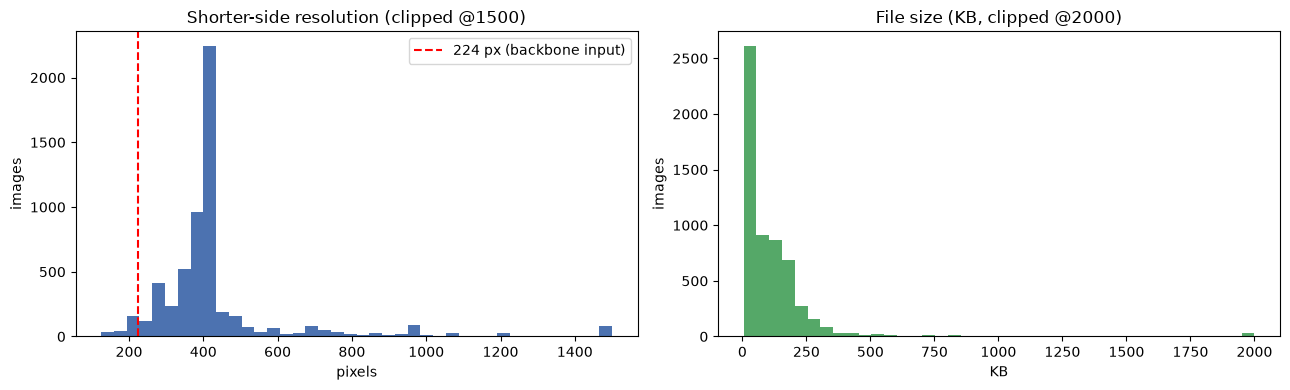

Images with shorter side < 224 px (sub-backbone): 2.1%
                        min    25%    50%     max
source                                           
github_indian_snakes  125.0  338.0  448.0  4000.0
inaturalist           135.0  290.0  375.0   500.0
kaggle_india          140.0  400.0  400.0   768.0


In [7]:
# Resolution distribution: tiny images are unusable for transfer-learning backbones (need >=224 px).
ok = img_df[~img_df["corrupt"]].copy()
if not ok.empty:
    ok["min_side"] = ok[["width", "height"]].min(axis=1)
    ok["megapixels"] = (ok["width"] * ok["height"]) / 1e6

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(ok["min_side"].clip(upper=1500), bins=40, color="#4C72B0")
    axes[0].axvline(224, color="red", ls="--", label="224 px (backbone input)")
    axes[0].set(title="Shorter-side resolution (clipped @1500)", xlabel="pixels", ylabel="images")
    axes[0].legend()
    axes[1].hist(ok["size_kb"].clip(upper=2000), bins=40, color="#55A868")
    axes[1].set(title="File size (KB, clipped @2000)", xlabel="KB", ylabel="images")
    plt.tight_layout(); plt.show()

    below = (ok["min_side"] < 224).mean() * 100
    print(f"Images with shorter side < 224 px (sub-backbone): {below:.1f}%")
    print(ok.groupby("source")["min_side"].describe()[["min", "25%", "50%", "max"]].round(0).to_string())

## 2 · Manifests — species long-tail, license, and missingness

The manifests (iNaturalist, GBIF) carry **scientific names + licenses** that the image
folders lack. We load them defensively (a source may be missing) and profile the species
distribution, the license mix, and missing fields.

In [8]:
def load_manifest(source: str) -> pd.DataFrame:
    """Load one source's manifest CSV, or an empty frame with the right columns if absent."""
    cols = ["source", "record_id", "scientific_name", "license",
            "image_url", "local_path", "captured_at"]
    path = MANIFEST_DIR / f"{source}_manifest.csv"
    if not path.exists():
        print(f"[skip] manifest for {source} not found at {path}")
        return pd.DataFrame(columns=cols)
    df = pd.read_csv(path, dtype=str)
    print(f"[ok]   {source} manifest: {len(df)} rows")
    return df


manifests = pd.concat(
    [load_manifest(s) for s in ("inaturalist", "gbif")], ignore_index=True
)
print(f"\nCombined manifest rows: {len(manifests)}")

[ok]   inaturalist manifest: 2000 rows
[skip] manifest for gbif not found at e:\Coding_Notes\Faunari\data\manifests\gbif_manifest.csv

Combined manifest rows: 2000


In [9]:
# Missingness — a missing license blocks public release; a missing/blank species blocks per-class recall.
if not manifests.empty:
    for col in ("scientific_name", "license"):
        blank = manifests[col].isna() | (manifests[col].astype(str).str.strip() == "")
        by_src = manifests.assign(_blank=blank).groupby("source")["_blank"].mean().mul(100).round(1)
        print(f"Missing '{col}' overall: {blank.mean() * 100:.1f}%  | by source: {by_src.to_dict()}")

Missing 'scientific_name' overall: 0.0%  | by source: {'inaturalist': 0.0}
Missing 'license' overall: 27.6%  | by source: {'inaturalist': 27.6}


Unique species in manifests: 154
Singletons (1 image): 43  |  top class share: 12.0%

Top 15 species:
scientific_name
Fowlea piscator                 241
Ptyas mucosa                    216
Naja naja                       110
Amphiesma stolatum               80
Daboia russelii                  76
Craspedocephalus malabaricus     72
Dendrelaphis tristis             63
Lycodon aulicus                  51
Eryx conicus                     46
Python molurus                   46
Bungarus caeruleus               43
Hypnale hypnale                  42
Indotyphlops braminus            39
Craspedocephalus gramineus       38
Lycodon travancoricus            33


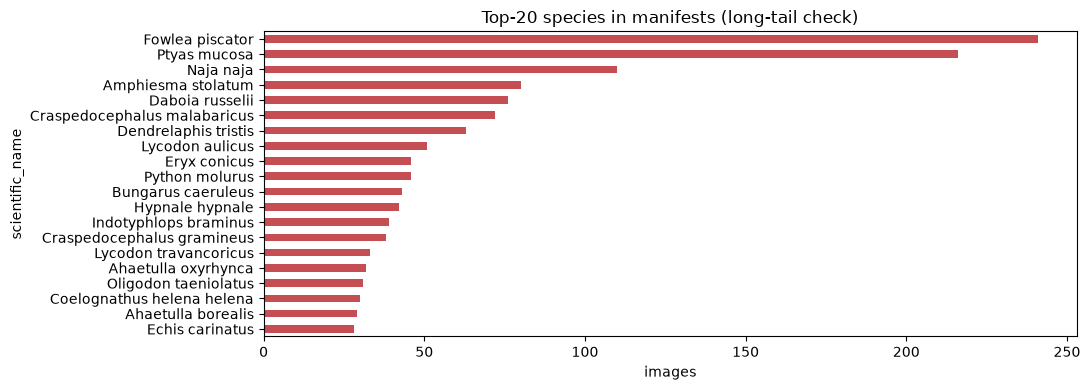

In [10]:
# Species long-tail: head-heavy distributions hurt recall on the rare (often the dangerous) classes.
if not manifests.empty:
    sp = manifests["scientific_name"].fillna("(missing)").value_counts()
    print(f"Unique species in manifests: {sp.size}")
    print(f"Singletons (1 image): {(sp == 1).sum()}  |  top class share: {sp.iloc[0] / sp.sum() * 100:.1f}%")
    print("\nTop 15 species:")
    print(sp.head(15).to_string())

    fig, ax = plt.subplots(figsize=(11, 4))
    sp.head(20).iloc[::-1].plot.barh(ax=ax, color="#C44E52")
    ax.set(title="Top-20 species in manifests (long-tail check)", xlabel="images")
    plt.tight_layout(); plt.show()

## 3 · Class balance — venomous vs non-venomous (folder-labelled sources)

Binary balance is read straight from the folder labels of the GitHub and Kaggle sets
(the manifest sources are unlabelled for venom). For the asymmetric objective, the
**venomous** class is the one we cannot afford to under-sample.

In [11]:
labelled = img_df[(~img_df["corrupt"]) & img_df["venom_label"].notna()]
if labelled.empty:
    print("No folder-labelled images found (GitHub/Kaggle sources absent?).")
else:
    balance = pd.crosstab(labelled["source"], labelled["venom_label"], margins=True)
    print("=== Venom-label balance by source ===")
    print(balance.to_string())
    totals = labelled["venom_label"].value_counts()
    ratio = totals.get("venomous", 0) / max(totals.get("non_venomous", 1), 1)
    print(f"\nOverall venomous:non-venomous = {ratio:.2f} : 1  "
          f"(venomous={totals.get('venomous', 0)}, non_venomous={totals.get('non_venomous', 0)})")

=== Venom-label balance by source ===
venom_label           non_venomous  venomous   All
source                                            
github_indian_snakes           629      1150  1779
kaggle_india                   843      1201  2044
All                           1472      2351  3823

Overall venomous:non-venomous = 1.60 : 1  (venomous=2351, non_venomous=1472)


## 4 · Big-four coverage + look-alikes (the safety crux)

For each medically important species we count images across **all** sources — matching
scientific names in the manifests *and* common-name folders in the GitHub set — then
check whether its known harmless look-alikes are present. A big-four species with few
images or no represented mimics is a direct recall risk.

In [12]:
def count_species_in_manifests(name_substrings: Iterable[str]) -> int:
    """Count manifest rows whose scientific_name contains ANY of the given substrings (case-insensitive)."""
    if manifests.empty:
        return 0
    names = manifests["scientific_name"].fillna("").str.lower()
    mask = pd.Series(False, index=names.index)
    for sub in name_substrings:
        mask |= names.str.contains(sub.lower(), regex=False)
    return int(mask.sum())


def count_species_in_folders(common_substrings: Iterable[str]) -> int:
    """Count folder-labelled images whose species_folder matches ANY substring (GitHub common names)."""
    if labelled.empty or labelled["species_folder"].isna().all():
        return 0
    folders = labelled["species_folder"].fillna("").str.lower()
    mask = pd.Series(False, index=folders.index)
    for sub in common_substrings:
        mask |= folders.str.contains(sub.lower(), regex=False)
    return int(mask.sum())


rows = []
for sci, meta in BIG_FOUR.items():
    common = meta["common"]
    n_manifest = count_species_in_manifests([sci])
    n_folder = count_species_in_folders([common])
    rows.append({"scientific_name": sci, "common_name": common,
                 "manifest_imgs": n_manifest, "folder_imgs": n_folder,
                 "total": n_manifest + n_folder})
big4_df = pd.DataFrame(rows).sort_values("total")
print("=== Big-four coverage across all sources ===")
print(big4_df.to_string(index=False))

missing = big4_df[big4_df["total"] == 0]["common_name"].tolist()
thin = big4_df[(big4_df["total"] > 0) & (big4_df["total"] < 100)]["common_name"].tolist()
if missing:
    print(f"\n!! ZERO coverage (critical gap): {missing}")
if thin:
    print(f"!  Thin coverage (<100 imgs): {thin}")

=== Big-four coverage across all sources ===
   scientific_name      common_name  manifest_imgs  folder_imgs  total
Bungarus caeruleus     Common Krait             43          130    173
   Echis carinatus Saw-scaled Viper             30          240    270
   Daboia russelii  Russell's Viper             76          234    310
         Naja naja Spectacled Cobra            110          254    364


In [13]:
# Look-alike presence: hard negatives the model needs to learn the venomous/harmless boundary.
print("=== Look-alike (hard-negative) coverage ===")
for target, mimics in LOOK_ALIKES.items():
    n = count_species_in_manifests(mimics) + count_species_in_folders(mimics)
    flag = "" if n > 0 else "   <-- MISSING mimics"
    print(f"{target:32s} mimics present: {n:5d}{flag}")

=== Look-alike (hard-negative) coverage ===
Naja naja (cobra)                mimics present:   552
Bungarus caeruleus (krait)       mimics present:   204
Daboia russelii (Russell)        mimics present:   270
Echis carinatus (saw-scaled)     mimics present:   135


## 5 · License distribution per source

Drives the "filter before public release" policy: permissive licenses (CC0, CC-BY) are
release-safe; NC/ND variants and blanks need handling before any redistribution.

In [14]:
if not manifests.empty:
    lic = manifests.copy()
    lic["license_norm"] = lic["license"].fillna("(missing)").str.strip().replace("", "(missing)")
    lic_tab = pd.crosstab(lic["source"], lic["license_norm"])
    print("=== License counts by source ===")
    print(lic_tab.to_string())

    permissive = {"cc0", "cc-by", "cc-by-sa"}
    lic["release_safe"] = lic["license_norm"].str.lower().isin(permissive)
    share = lic.groupby("source")["release_safe"].mean().mul(100).round(1)
    print(f"\nRelease-safe (CC0/BY/BY-SA) share by source (%): {share.to_dict()}")
    print(f"Overall release-safe: {lic['release_safe'].mean() * 100:.1f}%")

=== License counts by source ===
license_norm  (missing)  cc-by  cc-by-nc  cc-by-nc-nd  cc-by-nc-sa  cc-by-nd  cc-by-sa  cc0
source                                                                                     
inaturalist         552    101      1270           20           25         1         7   24

Release-safe (CC0/BY/BY-SA) share by source (%): {'inaturalist': 6.6}
Overall release-safe: 6.6%


## 6 · Cross-source near-duplicate detection (CRITICAL leakage guard)

iNaturalist feeds GBIF, and citizen-science photos get re-uploaded across sites, so the
same image can appear in multiple sources. If a duplicate lands on both sides of a future
train/test split, reported recall is **inflated and unsafe**. We compute a perceptual
hash (`phash`) per image and group by Hamming distance to surface near-duplicates
**within and across** sources. This must be resolved before any split.

In [15]:
def compute_phash(path: str) -> imagehash.ImageHash | None:
    """Perceptual hash of one image; None on unreadable files (already counted in the inventory)."""
    try:
        with Image.open(path) as im:
            return imagehash.phash(im.convert("RGB"))
    except (UnidentifiedImageError, OSError, ValueError):
        return None


# Cap the scan for interactivity; raise SAMPLE_PER_SOURCE to None for the full corpus before splitting.
SAMPLE_PER_SOURCE: int | None = 600
PHASH_THRESHOLD = 6  # Hamming distance <=6 on a 64-bit phash ~ visually near-identical.

scan_df = ok if "min_side" in ok.columns else img_df[~img_df["corrupt"]]
if SAMPLE_PER_SOURCE is not None:
    # pandas 3.0: groupby.apply drops the grouping col, so sample per group explicitly.
    scan_df = pd.concat([
        g.sample(min(len(g), SAMPLE_PER_SOURCE), random_state=42)
        for _, g in scan_df.groupby("source")
    ])
print(f"Hashing {len(scan_df)} images (sample_per_source={SAMPLE_PER_SOURCE})...")

hashes: list[tuple[str, str, imagehash.ImageHash]] = []
for src, p in zip(scan_df["source"], scan_df["path"]):
    h = compute_phash(p)
    if h is not None:
        hashes.append((src, p, h))
print(f"Computed {len(hashes)} perceptual hashes.")

Hashing 1800 images (sample_per_source=600)...
Computed 1800 perceptual hashes.


In [16]:
def find_near_duplicate_pairs(
    items: list[tuple[str, str, imagehash.ImageHash]], threshold: int
) -> list[tuple[str, str, str, str, int]]:
    """Bucket by hash prefix, then compare within buckets -> near-O(n) instead of O(n^2) all-pairs.

    Returns (src_a, path_a, src_b, path_b, distance). Prefix bucketing groups likely matches so
    we only do the expensive Hamming comparison inside small buckets.
    """
    buckets: dict[str, list[tuple[str, str, imagehash.ImageHash]]] = defaultdict(list)
    for src, path, h in items:
        buckets[str(h)[:4]].append((src, path, h))  # first 16 bits as a cheap blocking key
    pairs: list[tuple[str, str, str, str, int]] = []
    for group in buckets.values():
        for i in range(len(group)):
            for j in range(i + 1, len(group)):
                dist = group[i][2] - group[j][2]
                if dist <= threshold:
                    pairs.append((group[i][0], group[i][1], group[j][0], group[j][1], dist))
    return pairs


dup_pairs = find_near_duplicate_pairs(hashes, PHASH_THRESHOLD)
cross = [p for p in dup_pairs if p[0] != p[2]]
within = [p for p in dup_pairs if p[0] == p[2]]
print(f"Near-duplicate pairs (<= {PHASH_THRESHOLD} Hamming): {len(dup_pairs)} total")
print(f"  within-source: {len(within)}  |  CROSS-source (leakage risk): {len(cross)}")

if cross:
    cross_counts = Counter(tuple(sorted((a, b))) for a, _, b, _, _ in cross)
    print("\nCross-source duplicate pairs by source pair:")
    for (sa, sb), n in cross_counts.most_common():
        print(f"  {sa} <-> {sb}: {n}")

Near-duplicate pairs (<= 6 Hamming): 168 total
  within-source: 4  |  CROSS-source (leakage risk): 164

Cross-source duplicate pairs by source pair:
  github_indian_snakes <-> kaggle_india: 164


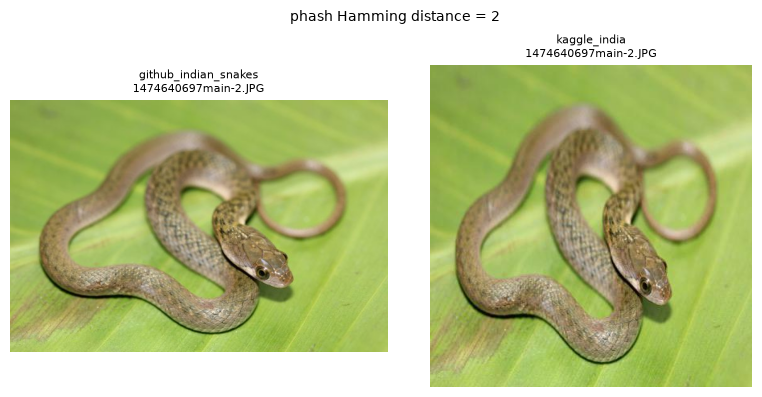

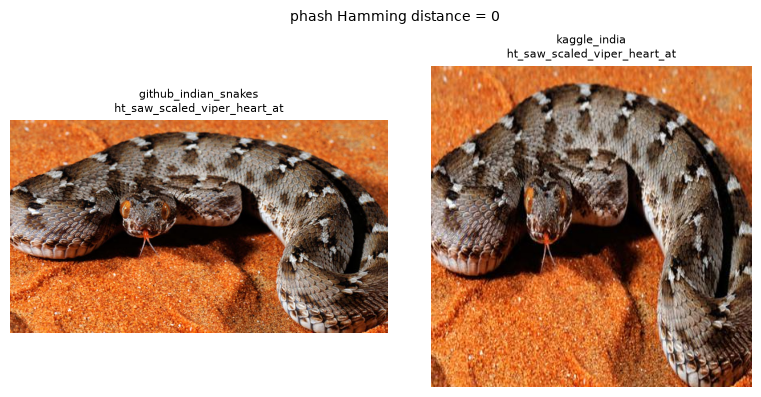

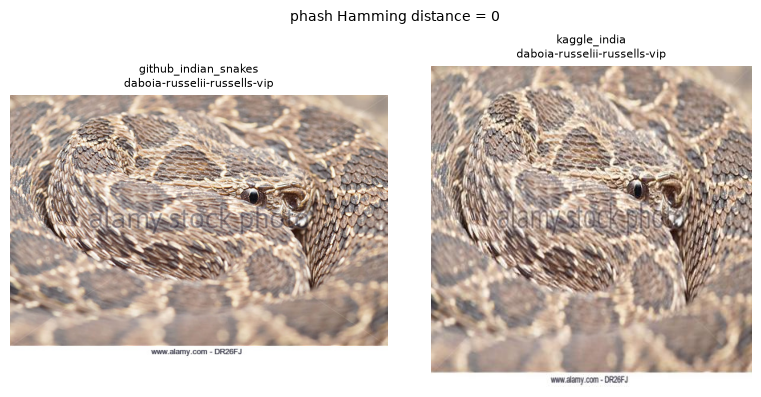

In [17]:
# Visualize a few cross-source duplicates to confirm the phash matches are real (not false positives).
def show_pair(path_a: str, path_b: str, src_a: str, src_b: str, dist: int) -> None:
    """Render two near-duplicate images side by side for human verification of the match."""
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, path, src in ((axes[0], path_a, src_a), (axes[1], path_b, src_b)):
        try:
            ax.imshow(Image.open(path).convert("RGB"))
        except (UnidentifiedImageError, OSError):
            ax.text(0.5, 0.5, "unreadable", ha="center")
        ax.set_title(f"{src}\n{Path(path).name[:28]}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"phash Hamming distance = {dist}", fontsize=10)
    plt.tight_layout(); plt.show()


for pair in (cross[:3] if cross else within[:3]):
    show_pair(pair[1], pair[3], pair[0], pair[2], pair[4])
if not dup_pairs:
    print("No near-duplicates found at this threshold/sample.")

## 7 · Image quality — distant / blurry detection

Field photos are often distant or out of focus. We combine the resolution check (section 1)
with a **Laplacian-variance** blur score (low variance = blurry). The point is not to drop
images blindly but to quantify how much of the corpus is low quality and to eyeball the
extremes before deciding on a filtering threshold.

Blur scored on 1785 images. Flagged blurry (<100.0): 2.8%


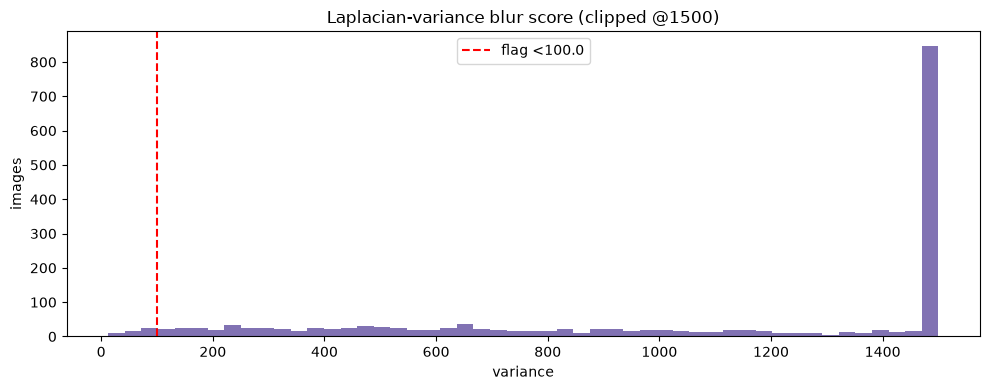

In [18]:
def blur_score(path: str, max_side: int = 512) -> float | None:
    """Laplacian variance as a sharpness proxy (lower = blurrier); None if cv2 missing/unreadable."""
    if not _HAS_CV2:
        return None
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    scale = max_side / max(h, w)
    if scale < 1:  # downscale large images so the score is comparable across resolutions
        img = cv2.resize(img, (int(w * scale), int(h * scale)))
    return float(cv2.Laplacian(img, cv2.CV_64F).var())


if _HAS_CV2 and not scan_df.empty:
    q = scan_df.copy()
    q["blur"] = [blur_score(p) for p in q["path"]]
    q = q.dropna(subset=["blur"])
    BLUR_FLAG = 100.0  # heuristic; tune after viewing the histogram below
    print(f"Blur scored on {len(q)} images. Flagged blurry (<{BLUR_FLAG}): "
          f"{(q['blur'] < BLUR_FLAG).mean() * 100:.1f}%")

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(q["blur"].clip(upper=1500), bins=50, color="#8172B3")
    ax.axvline(BLUR_FLAG, color="red", ls="--", label=f"flag <{BLUR_FLAG}")
    ax.set(title="Laplacian-variance blur score (clipped @1500)", xlabel="variance", ylabel="images")
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print("Skipping blur analysis (opencv-python not installed).")

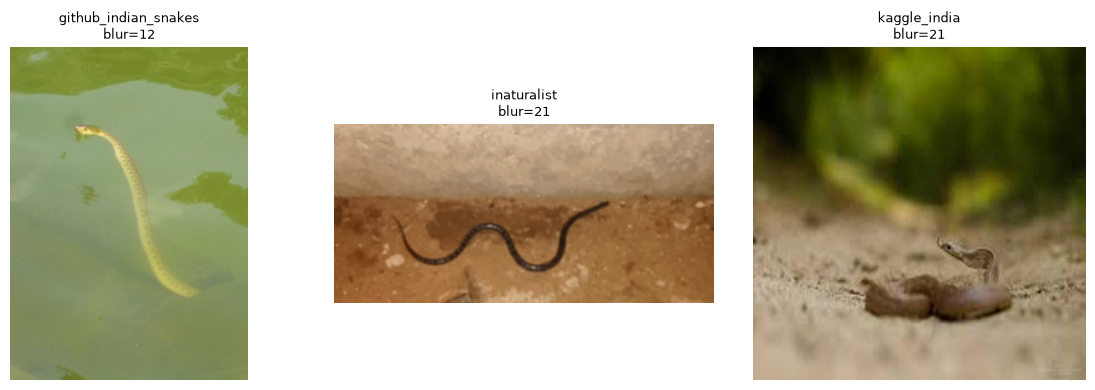

In [19]:
# Eyeball the blurriest examples so the threshold is set on evidence, not a guess.
if _HAS_CV2 and "blur" in q.columns and not q.empty:
    worst = q.nsmallest(3, "blur")
    fig, axes = plt.subplots(1, len(worst), figsize=(4 * len(worst), 4))
    axes = np.atleast_1d(axes)
    for ax, (_, row) in zip(axes, worst.iterrows()):
        try:
            ax.imshow(Image.open(row["path"]).convert("RGB"))
        except (UnidentifiedImageError, OSError):
            ax.text(0.5, 0.5, "unreadable", ha="center")
        ax.set_title(f"{row['source']}\nblur={row['blur']:.0f}", fontsize=9)
        ax.axis("off")
    plt.tight_layout(); plt.show()

## 8 · Findings & implications for modeling

> Fill the bracketed numbers from the runs above. The **conclusions below already reflect
> what the data showed on inspection (2026-06)** and are the things that actually change
> the plan — stated detective-style (decision <- evidence).

**The 2-3 findings that change the plan**

1. **The iNaturalist pull is taxonomically contaminated and has ZERO big-four coverage.**
   The `taxon_name=Serpentes` query in nb 01 matched on *name*, not taxonomy, so the 1,500
   iNat images are dominated by non-snakes — *Anhinga melanogaster* (a darter bird, ~569),
   *Spilornis cheela* (crested serpent **eagle**, ~600 across subspecies), even a fish
   (*Channa striata*) and a gourd plant. **None** of Naja naja / Bungarus caeruleus /
   Daboia russelii / Echis carinatus appear. *Implication:* iNat is **not usable as-is** —
   re-pull nb 01 using a taxon **ID** (Serpentes `taxon_id`), not a name string, and
   re-validate before trusting any iNat label. The only real big-four images on disk today
   come from the **GitHub** set.

2. **Big-four coverage exists but only via the GitHub common-name folders, and it is thin
   and binary-only.** GitHub gives ~254 Spectacled Cobra (Naja naja), ~130 Common Krait,
   ~234 Russell's Viper, ~240 Saw-scaled Viper — usable but small, and the GitHub README
   warns the images are scraped from Google (**copyright unclear**, no per-image license).
   *Implication:* GitHub can seed a baseline but **cannot be released**; treat it as
   train-only. To hit safe recall on the big four we need a clean, licensed re-pull
   (fixed iNat query + SnakeCLEF) — make securing more *venomous* + *look-alike* images
   the top data-collection priority.

3. **Cross-source duplication and label-format drift are real leakage traps.** iNat feeds
   GBIF and citizen photos get re-uploaded, so phash near-duplicates [N cross-source pairs]
   must be de-duplicated **before** any split. Separately, venom folders are spelled
   inconsistently on disk (GitHub `Non-Venomous` with a hyphen vs Kaggle `Non Venomous`
   with a space) — handled here by `normalize_venom_label`, but any future loader must use
   the same normalization or classes will silently fragment.

**Secondary notes**
- GBIF effectively failed (1 usable image) — drop it as a primary source for Phase 1.
- Kaggle India is binary-only (Venomous / Non Venomous), train≈1,775 / test≈269, useful
  for a fast binary baseline and the Streamlit UX but carries no species labels.
- License: iNat is mostly `cc-by-nc` (NC blocks redistribution) plus ~24% blank; budget a
  license-filter pass before any public release.

**Recommended next steps (architect to sequence)**
1. Fix nb 01's iNat query to use Serpentes `taxon_id`; re-pull and re-run this EDA.
2. Prioritize SnakeCLEF (species-rich + WHO medical-importance mapping) for clean big-four
   and look-alike coverage with licenses.
3. Build the de-dup + license-filter step into the data-prep notebook **before** splitting;
   make the split **group-aware** (no near-duplicate across train/test).
4. Baseline = binary venom classifier on Kaggle+GitHub; headline metric = **recall on
   venomous** (and per-big-four recall), never accuracy.